In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from Pruning import *
from scipy.linalg import solve, qr
import numpy as np
from Plot import *
import random

# Transform to tensor
dataset_transform = transforms.Compose([
    transforms.ToTensor(),                 
    #transforms.Normalize((0.1307,), (0.3081,))  # Normalization 
])

train_dataset = datasets.MNIST(
    root = "./data",      
    train = True,         
    download = True,      
    transform = dataset_transform
)

test_dataset = datasets.MNIST(
    root = "./data",
    train = False,        
    download = True,
    transform = dataset_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False
)

In [2]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps" if torch.mps.is_available() else "cpu")
#device = torch.device("cpu")
class Model1(nn.Module):
    def __init__(self):
        super(Model1, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 100),
            nn.ReLU(),
            nn.Linear(100, 10)
        )

    def forward(self, x):
        x = self.model(x)
        return x
    

model1 = Model1().to(device)


# loss functiom & optimizer
loss_fun = nn.CrossEntropyLoss()
optimizer = optim.SGD(model1.parameters(), lr=0.1, momentum=0.9)

train_data_size = len(train_dataset)
test_data_size = len(test_dataset)

In [3]:
epoch = 5

for i in range(epoch):
    print("-------Epoch {}-------".format(i+1))
    # train
    for imgs, targets in train_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)
        outputs = model1(imgs)
        loss = loss_fun(outputs, targets)

        # optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # test
    total_test_loss = 0
    total_accuracy = 0
    wrong_indices = []
    base_idx = 0
    with torch.no_grad():
        for imgs, targets in test_loader:
            batch_size = targets.size(0)
            imgs = imgs.to(device)
            targets = targets.to(device)
            outputs = model1(imgs)

            loss0 = loss_fun(outputs, targets)
            total_test_loss = total_test_loss + loss0.item()

            accuracy = (outputs.argmax(1) == targets).sum().item()
            total_accuracy = total_accuracy + accuracy

            # Record indices of misclassified samples
            if i == epoch - 1:  # Only record for the last epoch
                wrong_in_batch = torch.where(outputs.argmax(1) != targets)[0]
                wrong_indices.extend((base_idx + wrong_in_batch).tolist())
                base_idx += batch_size


    print("Total loss in test set: {}".format(total_test_loss))
    print("Total accuracy in test set: {}".format(total_accuracy / test_data_size))

print("Number of samples misclassified by the original model:", len(wrong_indices))

-------Epoch 1-------
Total loss in test set: 1.2863237112760544
Total accuracy in test set: 0.9602
-------Epoch 2-------
Total loss in test set: 0.9720113221555948
Total accuracy in test set: 0.9707
-------Epoch 3-------
Total loss in test set: 0.9776687175035477
Total accuracy in test set: 0.9719
-------Epoch 4-------
Total loss in test set: 1.0400706082582474
Total accuracy in test set: 0.9699
-------Epoch 5-------
Total loss in test set: 0.9812137428671122
Total accuracy in test set: 0.9734
Number of samples misclassified by the original model: 266


In [4]:
batch_list = list(train_loader)
X, _ = random.choice(batch_list)
X = X.to(device)
ratios = np.linspace(0.1, 0.9, 9)
base_acc = total_accuracy / test_data_size

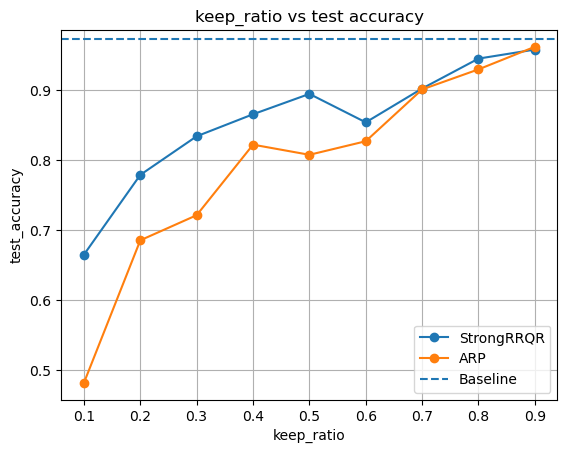

In [5]:
methods = ["StrongRRQR", "ARP"]
all_accs = []
for method in methods:
    accs = []
    for r in ratios:
        params_new = prune_model(model1, X, r, method=method)
        pruned_model = load_pruned_model(model1, params_new)
        acc, _ = evaluate_pruned_model(pruned_model, test_loader)
        accs.append(acc)
    all_accs.append(accs)

plot_pruning_curve(base_acc, ratios, all_accs, methods,
                   title="keep_ratio vs test accuracy")

In [6]:
params_new = prune_model(model1, X, 0.7, method="StrongRRQR")
pruned_model = load_pruned_model(model1, params_new)
acc, wrong_samples_pruned = evaluate_pruned_model(pruned_model, test_loader)
print(acc, len(wrong_samples_pruned))

0.9025 975


Number of samples misclassified by pruned model but not by original model: 788
Index: 795
Label: 3
Shape: torch.Size([1, 28, 28])
------------------------------
Index: 2389
Label: 8
Shape: torch.Size([1, 28, 28])
------------------------------
Index: 6594
Label: 2
Shape: torch.Size([1, 28, 28])
------------------------------


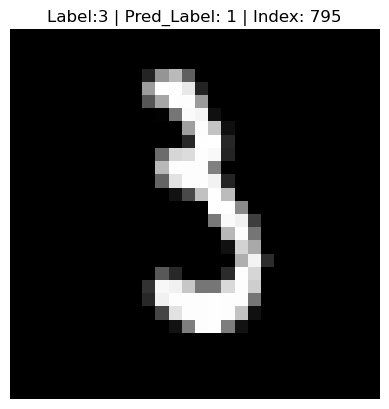

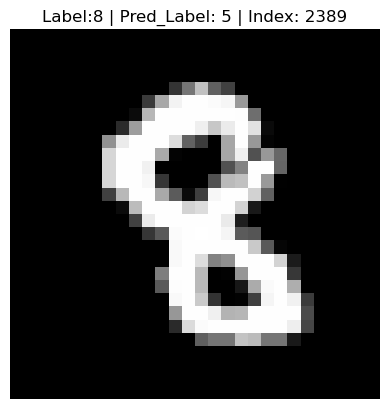

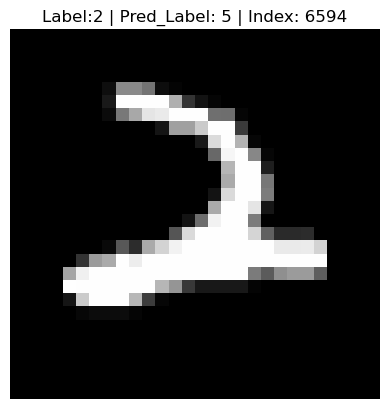

In [8]:
wrong_indices_pruned, wrong_pred_pruned = zip(*wrong_samples_pruned)
wrong_indices_pruned = list(wrong_indices_pruned)
wrong_pred_pruned = list(wrong_pred_pruned)

diff_indices = list(set(wrong_indices_pruned) - set(wrong_indices))
print("Number of samples misclassified by pruned model but not by original model:", len(diff_indices))

pred_dict_pruned = dict(wrong_samples_pruned)


random_indices = random.sample(diff_indices, 3)

for idx in random_indices[:3]:
    img, label = test_dataset[idx]
    print("Index:", idx)
    print("Label:", label)
    print("Shape:", img.shape)
    print("-" * 30)

for idx in random_indices[:3]:
    img, label = test_dataset[idx]
    pred_label = pred_dict_pruned[idx]

    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"Label:{label} | Pred_Label: {pred_label} | Index: {idx}")
    plt.axis('off')
    plt.show()

In [9]:
# Add the diff_indices in test set to the training set and retrain the model
from torch.utils.data import Subset, ConcatDataset

# extract the samples in the test set corresponding to diff_indices
diff_subset = Subset(test_dataset, diff_indices)

# New training set = original training set + diff_subset
new_train_dataset = ConcatDataset([train_dataset, diff_subset])

# New test set = remaining samples in the test set after removing diff_indices
diff_indices_set = set(diff_indices)
remain_test_indices = [i for i in range(len(test_dataset)) if i not in diff_indices_set]
new_test_dataset = Subset(test_dataset, remain_test_indices)

# New dataLoader
new_train_loader = DataLoader(new_train_dataset, batch_size=64, shuffle=True)
new_test_loader = DataLoader(new_test_dataset, batch_size=64, shuffle=False)

print("New training set size:", len(new_train_dataset))
print("New test set size:", len(new_test_dataset))


# Reinitialize the model
model1_new = Model1().to(device)
loss_fun = nn.CrossEntropyLoss()
optimizer = optim.SGD(model1_new.parameters(), lr=0.1, momentum=0.9)

for i in range(epoch):
    print("-------Epoch {}-------".format(i+1))
    # train
    for imgs, targets in new_train_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)
        outputs = model1_new(imgs)
        loss = loss_fun(outputs, targets)

        # optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # test
    total_test_loss = 0
    total_accuracy = 0
    wrong_indices = []
    base_idx = 0
    with torch.no_grad():
        for imgs, targets in new_test_loader:
            batch_size = targets.size(0)
            imgs = imgs.to(device)
            targets = targets.to(device)
            outputs = model1_new(imgs)

            loss0 = loss_fun(outputs, targets)
            total_test_loss = total_test_loss + loss0.item()

            accuracy = (outputs.argmax(1) == targets).sum().item()
            total_accuracy = total_accuracy + accuracy

            # Record indices of misclassified samples
            if i == epoch - 1:  # Only record for the last epoch
                wrong_in_batch = torch.where(outputs.argmax(1) != targets)[0]
                wrong_indices.extend((base_idx + wrong_in_batch).tolist())
                base_idx += batch_size
        
        print("Total loss in test set: {}".format(total_test_loss))
        print("Total accuracy in test set: {}".format(total_accuracy / test_data_size))


print("Number of samples misclassified by the retrained model:", len(wrong_indices))


New training set size: 60788
New test set size: 9212
-------Epoch 1-------
Total loss in test set: 15.359854047885165
Total accuracy in test set: 0.8922
-------Epoch 2-------
Total loss in test set: 19.47263052407652
Total accuracy in test set: 0.8821
-------Epoch 3-------
Total loss in test set: 15.625028692826163
Total accuracy in test set: 0.8905
-------Epoch 4-------
Total loss in test set: 13.773561280137073
Total accuracy in test set: 0.8964
-------Epoch 5-------
Total loss in test set: 12.141459329464851
Total accuracy in test set: 0.9004
Number of samples misclassified by the retrained model: 208


In [10]:
params_new = prune_model(model1_new, X, 0.7, method="StrongRRQR")
pruned_model = load_pruned_model(model1_new, params_new)
acc, wrong_samples_pruned = evaluate_pruned_model(pruned_model, new_test_loader)
print(acc, len(wrong_samples_pruned))

0.9180416847590099 755


Number of samples misclassified by pruned model but not by original model: 596
Index: 1496
Label: 2
Shape: torch.Size([1, 28, 28])
------------------------------
Index: 4409
Label: 8
Shape: torch.Size([1, 28, 28])
------------------------------
Index: 3058
Label: 9
Shape: torch.Size([1, 28, 28])
------------------------------


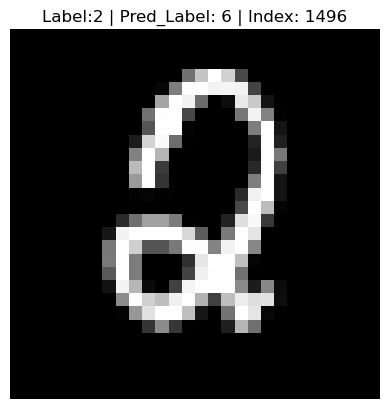

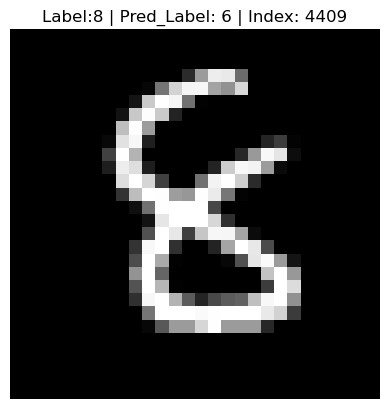

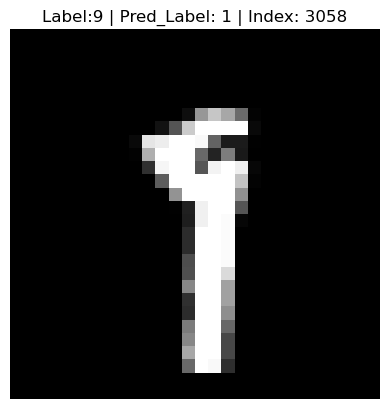

In [24]:
wrong_indices_pruned, wrong_pred_pruned = zip(*wrong_samples_pruned)
wrong_indices_pruned = list(wrong_indices_pruned)
wrong_pred_pruned = list(wrong_pred_pruned)

diff_indices = list(set(wrong_indices_pruned) - set(wrong_indices))
print("Number of samples misclassified by pruned model but not by original model:", len(diff_indices))

pred_dict_pruned = dict(wrong_samples_pruned)


random_indices = random.sample(diff_indices, 3)

for idx in random_indices[:3]:
    img, label = new_test_dataset[idx]
    print("Index:", idx)
    print("Label:", label)
    print("Shape:", img.shape)
    print("-" * 30)

for idx in random_indices[:3]:
    img, label = new_test_dataset[idx]
    pred_label = pred_dict_pruned[idx]

    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"Label:{label} | Pred_Label: {pred_label} | Index: {idx}")
    plt.axis('off')
    plt.show()